# NOVAPAY

### Import Libraries

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [179]:
# Load data
df_raw = pd.read_csv("/home/whizic/UK/AMDARI/NOVAPAY/nova_pay_combined.csv")
df = df_raw.copy()
df.shape

(11400, 26)

In [180]:
df.head(5)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [181]:
# Check for missing values
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [182]:
# check for data types
df.dtypes

transaction_id                object
customer_id                   object
timestamp                     object
home_country                  object
source_currency               object
dest_currency                 object
channel                       object
amount_src                    object
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                     object
new_device                      bool
ip_address                    object
ip_country                    object
location_mismatch               bool
ip_risk_score                float64
kyc_tier                      object
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [183]:
# examine the distribution of the target variable
df["is_fraud"].value_counts(normalize=True)

# from the output below, a simple model that predicts all transactions as non-fraudulent would achieve an accuracy of 91.25%, which is not a good metric here.
# Use prescision, recall, F1-score, and AUC-ROC or resampling techniques to evaluate the model performance.

is_fraud
0    0.912544
1    0.087456
Name: proportion, dtype: float64

### Data Cleaning

In [184]:
# convert timestamp to datetime, coercing invalid values to NaT (Not a Time)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [185]:
# convert amouunt_src to numeric float, setting non-numeric values to NaN
df['amount_src'] = (
    df['amount_src']
      .astype(str)
      .str.replace(',', '', regex=False)
      .str.strip()
)
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')

In [186]:
# amount in source currency have no missing values, but amount in USD has missing values. This could be a conversion(exchange) rate issue.
# calculate exchange rate per currency
# select only the rows where amount_usd is not null
# group by source_currency
# calculate the mean exchange rate for each source_currency
# convert the result to a dictionary for easy lookup
exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(lambda x: (x['amount_usd'] / x['amount_src']).mean()).to_dict()

/tmp/ipykernel_408760/433929445.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(lambda x: (x['amount_usd'] / x['amount_src']).mean()).to_dict()


In [187]:
# display the exchange rates for each source currency
exchange_rates

{'CAD': 0.7216095926871465,
 'GBP': 1.2234540399539093,
 'USD': 0.9838792221084954}

In [188]:
# check for all source currencies in the dataset
df['source_currency'].value_counts()

source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [189]:
# fill in missing amount_usd values using the calculated exchange rates
# if amount_usd is already present, keep it; 
# if not, calculate it using amount_src multiplied by the exchange rate for the corresponding source_currency
# default to 1 if the currency is not found in the exchange_rates dictionary
df['amount_usd'] = df.apply(
  lambda row: row['amount_usd'] if pd.notna(row['amount_usd']) else row['amount_src'] * exchange_rates.get(row['source_currency'], 1), axis=1) 

In [190]:
# fill missing values for fee using the median of the channel
# then fill any remaining missing values with the overall median
df['fee'] = df.groupby('channel')['fee'].transform(lambda x: x.fillna(x.median()))

In [191]:
# fill missing ip_country with the equivalent home_country
if {'ip_country', 'home_country'}.issubset(df.columns):
    df['ip_country'] = df['ip_country'].fillna(df['home_country'])


In [192]:
# fill missing data for kyc_tier using the mode
if 'kyc_tier' in df.columns:
    mode_kyc_tier = df['kyc_tier'].mode().iloc[0] if not df['kyc_tier'].mode().empty else "standard"  # default to "standard" if mode is empty
    df['kyc_tier'] = df['kyc_tier'].fillna(mode_kyc_tier)

In [193]:
# fill missing value for device_trust_score
# if device_trust_score and kyc_tier are present, fill missing score per group using the group median 
# fill any remaining missing values with the overall median
if 'device_trust_score' in df.columns and 'kyc_tier' in df.columns:
    df['device_trust_score'] = df.groupby('kyc_tier')['device_trust_score'].transform(lambda x: x.fillna(x.median()))
    df['device_trust_score'] = df['device_trust_score'].fillna(df['device_trust_score'].median())

/home/whizic/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/whizic/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [194]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     61
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [195]:
df.dropna(inplace=True)

In [196]:
df.shape

(11034, 26)

In [197]:
### Sanity Checks
df.describe(include='all')

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11034,11034,11034,11034,11034,11034,11034,11034.000000,11034.000000,11034.000000,11034.000000,11034,11034,11034,11034,11034,11034.000000,11034,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000
unique,10840,1314,NaN,7,3,9,12,NaN,NaN,NaN,NaN,2112,2,10840,7,2,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,7e762adf-98c5-48e5-900a-b6afee5ade30,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,NGN,mobile,NaN,NaN,NaN,NaN,e70db499-19e1-4927-b04f-3ebfcf62e33c,False,172.12.12.17,US,False,NaN,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1458,NaN,7687,7773,1426,6136,NaN,NaN,NaN,NaN,83,9716,2,6812,9221,NaN,7885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2024-05-03 12:57:12.877111296+00:00,NaN,NaN,NaN,NaN,440.498887,451.585603,98.186659,167.638276,NaN,NaN,NaN,NaN,NaN,0.397754,NaN,392.967917,0.654239,0.050027,0.268048,0.469730,0.739804,0.045556,0.089451
min,NaN,NaN,2022-10-03 18:40:59.468549+00:00,NaN,NaN,NaN,NaN,-9997.160000,7.230000,-1.000000,0.592000,NaN,NaN,NaN,NaN,NaN,0.004000,NaN,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2023-08-15 04:32:57.718548992+00:00,NaN,NaN,NaN,NaN,90.895000,92.570000,2.382500,1.000000,NaN,NaN,NaN,NaN,NaN,0.209000,NaN,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,2024-05-09 05:02:37.968549120+00:00,NaN,NaN,NaN,NaN,159.120000,163.645000,3.510000,7.142857,NaN,NaN,NaN,NaN,NaN,0.325000,NaN,286.500000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,2025-01-29 13:30:40.468549120+00:00,NaN,NaN,NaN,NaN,295.147500,302.447500,5.550000,73.529412,NaN,NaN,NaN,NaN,NaN,0.488000,NaN,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,NaN,NaN,2025-12-16 00:13:41.468549+00:00,NaN,NaN,NaN,NaN,11942.890000,12498.570000,9999.990000,1388.888889,NaN,NaN,NaN,NaN,NaN,1.200000,NaN,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [198]:
# count negative values in key numeric columns
numeric_columns = ['amount_src', 'amount_usd', 'fee', 'device_trust_score', 'txn_velocity_1h', 'txn_velocity_24h', 'risk_score_internal']
negative_values_count = {col: (df[col] < 0).sum() for col in numeric_columns}
negative_values_count

{'amount_src': np.int64(100),
 'amount_usd': np.int64(0),
 'fee': np.int64(94),
 'device_trust_score': np.int64(194),
 'txn_velocity_1h': np.int64(194),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [199]:
# keep only values greater than or equal to zero for the key numeric columns
for col in numeric_columns:
    df = df[df[col] >= 0]

In [200]:
# check for correlation between amount_usd and amount_src
(df["amount_usd"]/df["amount_src"]).describe()

count    10840.000000
mean         1.018123
std          0.136521
min          0.739788
25%          1.000000
50%          1.000000
75%          1.000000
max          1.250405
dtype: float64

In [201]:
# check for future timestamps in the dataset
df[df['timestamp'] > pd.Timestamp.utcnow()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [202]:
# check for location mismatch
df['location_mismatch'].value_counts()

location_mismatch
False    9047
True     1793
Name: count, dtype: int64

In [203]:
# check for unique value counts in categorical columns
categorical_columns = ['home_country', 'source_currency', 'channel', 'dest_currency', 'kyc_tier'] 
unique_value_counts = {col: df[col].unique() for col in categorical_columns}
unique_value_counts

{'home_country': array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
       dtype=object),
 'source_currency': array(['USD', 'CAD', 'GBP'], dtype=object),
 'channel': array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'unknown',
        'mobille', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object),
 'dest_currency': array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
       dtype=object),
 'kyc_tier': array(['standard', 'enhanced', 'low', ' standard  ', 'standrd',
        ' enhanced  ', 'STANDARD', 'unknown', 'enhancd', ' low  ',
        'ENHANCED', 'LOW'], dtype=object)}

In [204]:
# resolve the spacing in home_country and replace unknown with np.nan
df['home_country'] = df['home_country'].str.strip()

In [205]:
# resolve case sensitivity in channel, spelling errors and unknown values
df['channel'] = df['channel'].str.strip().str.lower()
df['channel'] = df['channel'].replace({'unknown': np.nan, 'weeb': 'web', 'mobille': 'mobile'})


In [206]:
# resolve case sensitivity in kyc_tier and replace unknown with np.nan, and spelling errors
df['kyc_tier'] = df['kyc_tier'].str.strip().str.lower()
df['kyc_tier'] = df['kyc_tier'].replace({'unknown': np.nan, 'standrd': 'standard', 'enhancd': 'enhanced'})

In [207]:
# check for missing values
df.isnull().sum()

transaction_id                0
customer_id                   0
timestamp                     0
home_country                  0
source_currency               0
dest_currency                 0
channel                      36
amount_src                    0
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_address                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                     29
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
dtype: int64

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             10840 non-null  object             
 1   customer_id                10840 non-null  object             
 2   timestamp                  10840 non-null  datetime64[ns, UTC]
 3   home_country               10840 non-null  object             
 4   source_currency            10840 non-null  object             
 5   dest_currency              10840 non-null  object             
 6   channel                    10804 non-null  object             
 7   amount_src                 10840 non-null  float64            
 8   amount_usd                 10840 non-null  float64            
 9   fee                        10840 non-null  float64            
 10  exchange_rate_src_to_dest  10840 non-null  float64            
 11  device_

In [209]:
# drop any remaining rows with missing values
df.dropna(inplace=True)

### Exploratory Data Analysis and Feature Engineering

In [210]:
# explore correlation between numeric features and the target variable
df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

is_fraud                     1.000000
txn_velocity_24h             0.759866
txn_velocity_1h              0.698681
risk_score_internal          0.612653
ip_risk_score                0.591583
chargeback_history_count     0.585117
location_mismatch            0.428793
new_device                   0.389261
corridor_risk                0.198449
exchange_rate_src_to_dest    0.154757
amount_usd                   0.131411
amount_src                   0.130744
fee                          0.130538
account_age_days            -0.291430
device_trust_score          -0.440364
Name: is_fraud, dtype: float64

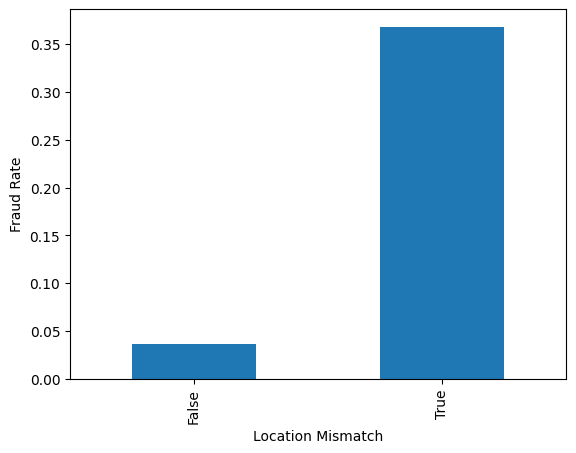

In [211]:

# examine location mismatch with respect to the target variable
df.groupby('location_mismatch')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Location Mismatch')
plt.show()

In [212]:
# explore correlation between categorical features and the target variable
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols

Index(['transaction_id', 'customer_id', 'home_country', 'source_currency',
       'dest_currency', 'channel', 'device_id', 'ip_address', 'ip_country',
       'kyc_tier'],
      dtype='object')

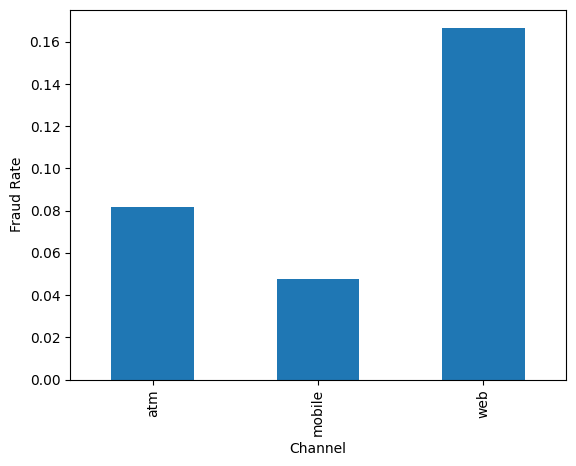

In [213]:
# explore correleation between channel and the target variable
df.groupby('channel')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Channel')
plt.show()

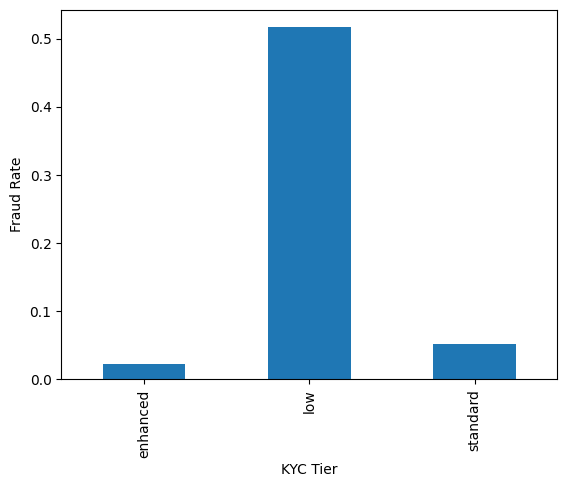

In [214]:
# explore correlation between kyc_tier and the target variable
df.groupby('kyc_tier')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('KYC Tier')
plt.show()

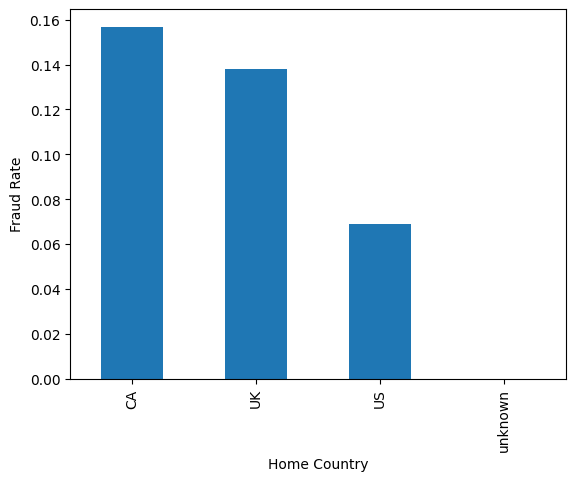

In [215]:
# explore correlation between home_country and the target variable
df.groupby('home_country')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Home Country')
plt.show()

### Feature Engineering

In [216]:
# display timestamp format
df['timestamp'].unique()

<DatetimeArray>
['2022-10-03 18:40:59.468549+00:00', '2022-10-03 20:39:38.468549+00:00',
 '2022-10-03 23:02:43.468549+00:00', '2022-10-04 01:08:53.468549+00:00',
 '2022-10-04 09:35:03.468549+00:00', '2022-10-04 12:09:59.468549+00:00',
 '2022-10-04 12:37:41.468549+00:00', '2022-10-04 16:27:44.468549+00:00',
 '2022-10-04 21:00:36.468549+00:00', '2022-10-04 21:20:42.468549+00:00',
 ...
 '2025-11-24 13:42:17.573611+00:00', '2025-11-25 00:45:10.573611+00:00',
 '2025-11-25 07:44:29.573611+00:00', '2025-11-25 07:56:54.573611+00:00',
 '2025-11-25 09:48:28.573611+00:00', '2025-11-25 10:05:35.573611+00:00',
 '2025-11-26 07:09:56.573611+00:00', '2025-11-27 06:19:11.573611+00:00',
 '2025-11-28 00:53:28.573611+00:00', '2025-11-29 20:10:47.573611+00:00']
Length: 10590, dtype: datetime64[ns, UTC]

In [217]:
# check for invalid timestamps in the dataset
parsed = pd.to_datetime(df['timestamp'], errors='coerce')
invalid_timestamps = df[parsed.isna()]
print(invalid_timestamps[['timestamp']].drop_duplicates())
print("\nCount:", len(invalid_timestamps))


Empty DataFrame
Columns: [timestamp]
Index: []

Count: 0


In [218]:
# from timestamp, extract the hour of the day, day of the week, and weekend indicator
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("Timestamp Features:")
print(df[['timestamp', 'hour_of_day', 'day_of_week', 'is_weekend']].head())
print("\nHour of Day Distribution:")
print(df['hour_of_day'].value_counts())

Timestamp Features:
                         timestamp  hour_of_day  day_of_week  is_weekend
0 2022-10-03 18:40:59.468549+00:00           18            0           0
1 2022-10-03 20:39:38.468549+00:00           20            0           0
2 2022-10-03 23:02:43.468549+00:00           23            0           0
3 2022-10-04 01:08:53.468549+00:00            1            1           0
4 2022-10-04 09:35:03.468549+00:00            9            1           0

Hour of Day Distribution:
hour_of_day
4     503
19    491
3     480
23    477
8     471
5     471
15    467
18    467
6     464
16    461
0     452
22    450
12    447
10    444
13    444
7     439
20    434
9     425
11    424
21    423
17    422
14    413
2     413
1     398
Name: count, dtype: int64



Hourly Fraud Rate:


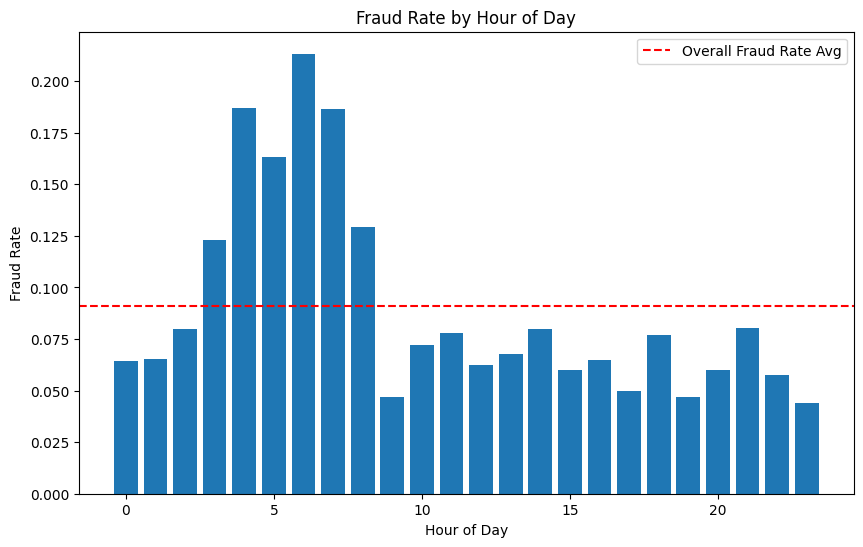

In [219]:
# examine hour and target variable relationship
hourly_fraud_rate = df.groupby('hour_of_day')['is_fraud'].mean()
print("\nHourly Fraud Rate:")

plt.figure(figsize=(10, 6))
plt.bar(hourly_fraud_rate.index, hourly_fraud_rate.values)
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()


Daily Fraud Rate:


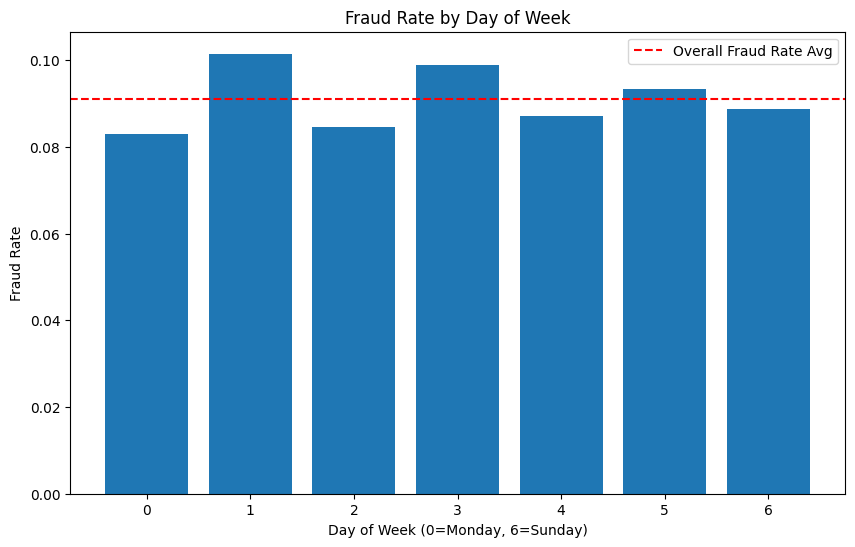

In [220]:
# examnine day of week and target variable relationship
daily_fraud_rate = df.groupby('day_of_week')['is_fraud'].mean()
print("\nDaily Fraud Rate:")
plt.figure(figsize=(10, 6))
plt.bar(daily_fraud_rate.index, daily_fraud_rate.values)
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

Fraud Rate by Account Age Bucket:
age_bucket
0-30d       0.368681
31-90d      0.442584
91-180d     0.023736
181-365d    0.016901
365+        0.010534
Name: is_fraud, dtype: float64


/tmp/ipykernel_408760/3563885290.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()


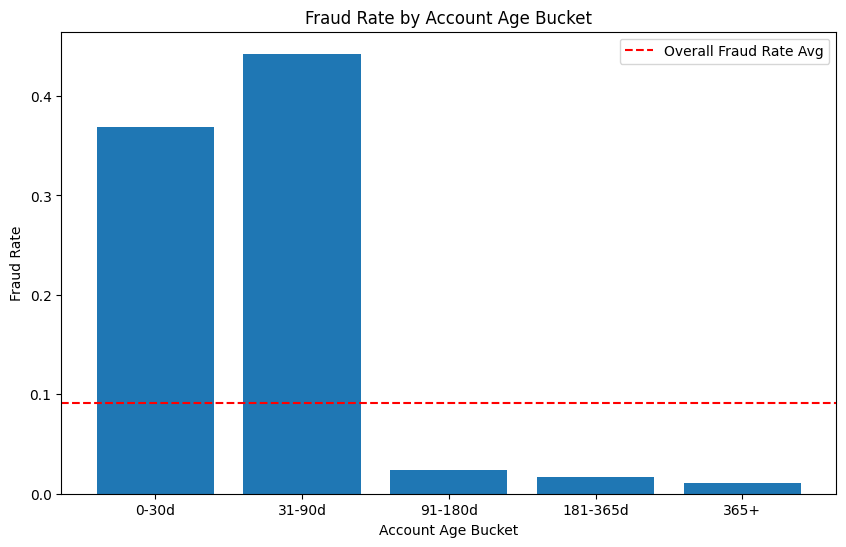

In [221]:
# examine account age and target variable relationship
df['age_bucket'] = pd.cut(df['account_age_days'], bins=[0, 30, 90, 180, 365, 2000], labels=['0-30d', '31-90d', '91-180d', '181-365d', '365+'])

fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()
print("Fraud Rate by Account Age Bucket:")
print(fraud_by_age)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_age)), fraud_by_age.values)
plt.xticks(range(len(fraud_by_age)), fraud_by_age.index)
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Account Age Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

In [222]:
df['account_age_days'].describe()

count    10780.00000
mean       393.49898
std        342.17545
min          1.00000
25%        147.00000
50%        285.00000
75%        661.00000
max       1095.00000
Name: account_age_days, dtype: float64

Fraud Rate by Transaction Velocity (1h):
txn_velocity_1h
0    0.017459
1    0.000000
2    0.000000
3    0.835878
4    0.842324
5    0.801047
6    0.700000
7    0.702703
8    0.482759
Name: is_fraud, dtype: float64


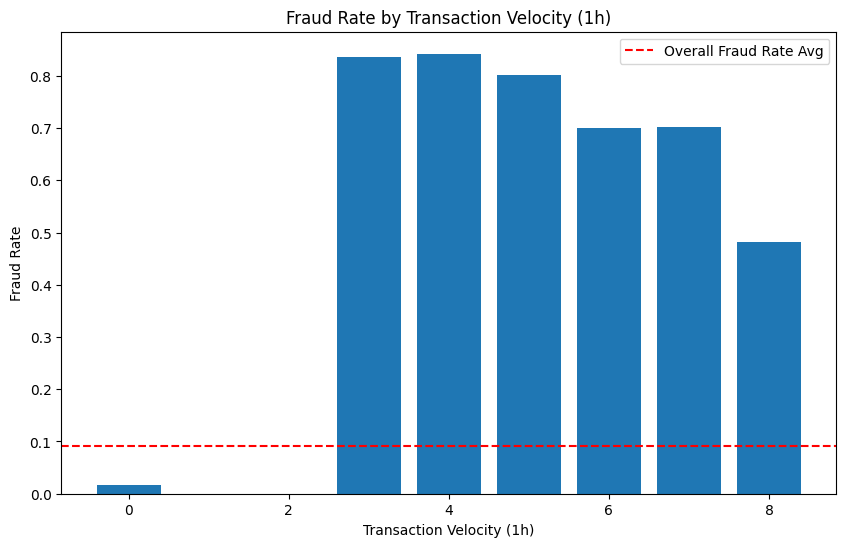

In [223]:
# examine velocity rate and target variable relationship
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean()
print("Fraud Rate by Transaction Velocity (1h):")
print(fraud_by_velocity)

plt.figure(figsize=(10, 6))
plt.bar(fraud_by_velocity.index, fraud_by_velocity.values)
plt.xlabel('Transaction Velocity (1h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (1h)')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

/tmp/ipykernel_408760/2343236712.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amount = df.groupby('amount_usd_bucket')['is_fraud'].mean()


Fraud Rate by Amount USD Bucket:
amount_usd_bucket
0-10          0.000000
11-50         0.020859
51-100        0.016887
101-500       0.061642
501-1000      0.301768
1001-5000     0.744318
5001-10000    0.136842
10001+        0.166667
Name: is_fraud, dtype: float64


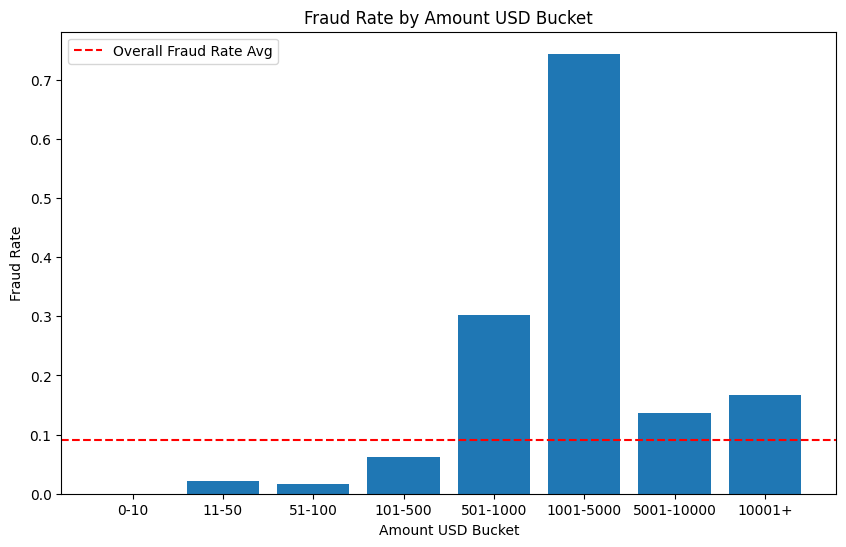

In [224]:
# examine amount_usd and target variable relationship
df['amount_usd_bucket'] = pd.cut(df['amount_usd'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, np.inf], labels=['0-10', '11-50', '51-100', '101-500', '501-1000', '1001-5000', '5001-10000', '10001+'])

fraud_by_amount = df.groupby('amount_usd_bucket')['is_fraud'].mean()
print("Fraud Rate by Amount USD Bucket:")
print(fraud_by_amount)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_amount)), fraud_by_amount.values)
plt.xticks(range(len(fraud_by_amount)), fraud_by_amount.index)
plt.xlabel('Amount USD Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Amount USD Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

Fraud Rate by Risk Score Internal Bucket:
risk_score_internal_bucket
0-0.2      0.011902
0.2-0.4    0.037893
0.4-0.6    0.219802
0.6-0.8    1.000000
0.8-1.0    1.000000
Name: is_fraud, dtype: float64


/tmp/ipykernel_408760/3197976394.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_risk_score = df.groupby('risk_score_internal_bucket')['is_fraud'].mean()


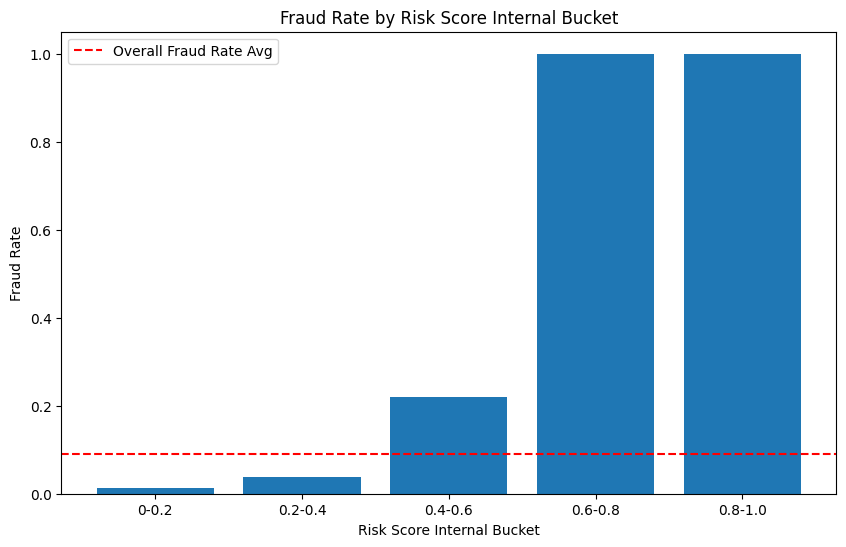

In [225]:
# examine ip risk score and target variable relationship
df['risk_score_internal_bucket'] = pd.cut(df['risk_score_internal'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

fraud_by_risk_score = df.groupby('risk_score_internal_bucket')['is_fraud'].mean()
print("Fraud Rate by Risk Score Internal Bucket:")
print(fraud_by_risk_score)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_risk_score)), fraud_by_risk_score.values)
plt.xticks(range(len(fraud_by_risk_score)), fraud_by_risk_score.index)
plt.xlabel('Risk Score Internal Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Risk Score Internal Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

/tmp/ipykernel_408760/3524538828.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean()


Fraud Rate by Device Trust Score Bucket:
device_trust_score_bucket
0-0.2      0.811508
0.2-0.4    0.203959
0.4-0.6    0.040541
0.6-0.8    0.018776
0.8-1.0    0.021694
Name: is_fraud, dtype: float64


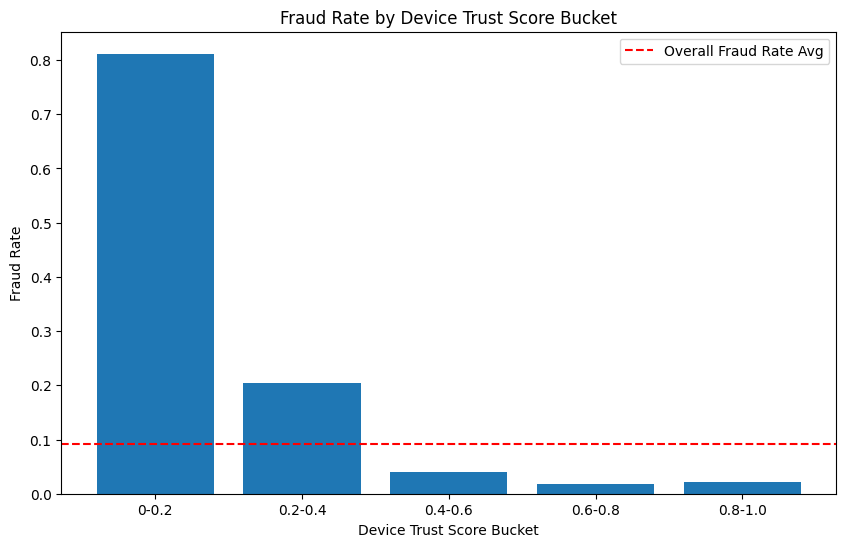

In [226]:
# examine device trust score and target variable relationship
df['device_trust_score_bucket'] = pd.cut(df['device_trust_score'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])
fraud_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean()
print("Fraud Rate by Device Trust Score Bucket:")
print(fraud_by_device_trust_score)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_device_trust_score)), fraud_by_device_trust_score.values)
plt.xticks(range(len(fraud_by_device_trust_score)), fraud_by_device_trust_score.index)
plt.xlabel('Device Trust Score Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Device Trust Score Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

In [227]:
# Based on the EDA, create a threshold-based features
df['night_time_transaction'] = ((df['hour_of_day'] >= 3) & (df['hour_of_day'] <= 8)).astype(int)
df['velocity_high'] = (df['txn_velocity_1h'] >= 3).astype(int)
df['amount_high'] = (df['amount_usd'] >= 500).astype(int)
df['ip_risk_high'] = (df['risk_score_internal'] >= 0.6).astype(int)
df['device_trust_low'] = (df['device_trust_score'] <= 0.4).astype(int)
df['account_age_very_new'] = (df['account_age_days'] <= 30).astype(int)
df['account_age_new'] = (df['account_age_days'] >= 30) & (df['account_age_days'] <= 90).astype(int)

print("New Features Created:")
print(df[['night_time_transaction', 'velocity_high', 'amount_high', 'ip_risk_high', 'device_trust_low', 'account_age_very_new', 'account_age_new']].describe())

New Features Created:


       night_time_transaction  velocity_high   amount_high  ip_risk_high  \
count            10780.000000   10780.000000  10780.000000  10780.000000   
mean                 0.262338       0.098516      0.126531      0.039054   
std                  0.439926       0.298025      0.332462      0.193732   
min                  0.000000       0.000000      0.000000      0.000000   
25%                  0.000000       0.000000      0.000000      0.000000   
50%                  0.000000       0.000000      0.000000      0.000000   
75%                  1.000000       0.000000      0.000000      0.000000   
max                  1.000000       1.000000      1.000000      1.000000   

       device_trust_low  account_age_very_new  
count      10780.000000          10780.000000  
mean           0.201391              0.168831  
std            0.401058              0.374620  
min            0.000000              0.000000  
25%            0.000000              0.000000  
50%            0.000000    

In [228]:
# drop the temporary bucket columns and select final features for modeling
df.drop(['age_bucket', 'amount_usd_bucket', 'risk_score_internal_bucket', 'device_trust_score_bucket'], axis=1)

# define the features
categorical_features = ['home_country', 'source_currency', 'channel', 
                        'dest_currency', 'kyc_tier', 'ip_country', 
                        'location_mismatch', 'new_device']

numeric_features = ['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 
                    'device_trust_score', 'txn_velocity_1h', 'txn_velocity_24h', 
                    'risk_score_internal', 'corridor_risk', 'account_age_days', 'hour_of_day', 'day_of_week',
                    'is_weekend', 'night_time_transaction', 'velocity_high',
                    'amount_high', 'ip_risk_high', 'device_trust_low',
                    'account_age_very_new', 'account_age_new']

all_features = categorical_features + numeric_features

print(f"total features: {len(all_features)}")
print(f"categorical features: {len(categorical_features)}")
print(f"numeric features: {len(numeric_features)}")
print(f"Dataset shape: {df.shape}")

total features: 28
categorical features: 8
numeric features: 20
Dataset shape: (10780, 40)


In [229]:
# display all columns headers
df.columns.tolist()

['transaction_id',
 'customer_id',
 'timestamp',
 'home_country',
 'source_currency',
 'dest_currency',
 'channel',
 'amount_src',
 'amount_usd',
 'fee',
 'exchange_rate_src_to_dest',
 'device_id',
 'new_device',
 'ip_address',
 'ip_country',
 'location_mismatch',
 'ip_risk_score',
 'kyc_tier',
 'account_age_days',
 'device_trust_score',
 'chargeback_history_count',
 'risk_score_internal',
 'txn_velocity_1h',
 'txn_velocity_24h',
 'corridor_risk',
 'is_fraud',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'age_bucket',
 'amount_usd_bucket',
 'risk_score_internal_bucket',
 'device_trust_score_bucket',
 'night_time_transaction',
 'velocity_high',
 'amount_high',
 'ip_risk_high',
 'device_trust_low',
 'account_age_very_new',
 'account_age_new']

### Modelling

In [230]:
# Sort by timestamp to ensure the data is in chronological order
df = df.sort_values('timestamp').reset_index(drop=True)

# 80/20 split
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print(f"Train: {len(train_df)} rows ({train_df['is_fraud'].sum()} fraud, {train_df['is_fraud'].mean():.3f} rate)")
print(f"Test: {len(test_df)} rows ({test_df['is_fraud'].sum()} fraud, {test_df['is_fraud'].mean():.3f} rate)")

# Prepare X and y for training and testing
X_train = train_df[all_features]
y_train = train_df['is_fraud']
X_test = test_df[all_features]
y_test = test_df['is_fraud']

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Train: 8624 rows (673 fraud, 0.078 rate)
Test: 2156 rows (308 fraud, 0.143 rate)

X_train shape: (8624, 28), y_train shape: (8624,)
X_test shape: (2156, 28), y_test shape: (2156,)


In [231]:
# import one-hot encoder for categorical features and standard scaler for numeric features
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# build a preprocessing pipeline for categorical and numeric features
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# fit the preprocessor on the training data and transform both training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Original features: {len(all_features)} After one-hot encoding, the number of features increased to: {X_train_processed.shape[1]}")

Processed X_train shape: (8624, 45)
Original features: 28 After one-hot encoding, the number of features increased to: 45


In [232]:
# Baseline model: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

# Train a logistic regression model with balanced class weights to handle class imbalance
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_processed, y_train)

# Predict on the test set
y_pred_lr = logreg.predict(X_test_processed)
y_pred_proba_lr = logreg.predict_proba(X_test_processed)[:, 1]

# Evaluate the model
print("Logistic Regression Results:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")


Logistic Regression Results:
Confusion Matrix:
[[1778   70]
 [  16  292]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.96      0.98      1848
       Fraud       0.81      0.95      0.87       308

    accuracy                           0.96      2156
   macro avg       0.90      0.96      0.92      2156
weighted avg       0.96      0.96      0.96      2156

ROC AUC Score: 0.9827


### Logistic Regression Interpretation
- Missed frauds = 16 i.e model catches 292 out of 308 frauds. 
- False alarms = 70 legitimate transactions flagged as fraud.
- Model finds most frauds (95% high recall), but 19% of its fraud alerts are false alarms (81% precision), giving an F1-score of 87%.
- ROC AUC 98% confirms the model separates classes well

In [233]:
# Baseline model: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest Classifier with balanced class weights
rf_clf = RandomForestClassifier(
  class_weight='balanced', 
  n_estimators=100, 
  max_depth=10,
  random_state=42,
  n_jobs=-1)
rf_clf.fit(X_train_processed, y_train)

# Predict on the test set
y_pred_rf = rf_clf.predict(X_test_processed)
y_pred_proba_rf = rf_clf.predict_proba(X_test_processed)[:, 1]

# Evaluate the Random Forest model
print("Random Forest Classifier Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")


Random Forest Classifier Results:
confusion_matrix:
[[1848    0]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      1848
       Fraud       1.00      0.92      0.96       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.98      2156
weighted avg       0.99      0.99      0.99      2156


ROC AUC Score: 0.9734


### Random Forest Interpretation
- Missed frauds: 25 i.e. model catches 283 out of 308 frauds.
- False alarms: 0 legitimate transactions flagged as fraud (perfect precision).
- Very high precision (100%) and strong recall (92%) giving an F1-score of 96%. few missed frauds and no false positive.
- ROC AUC 97% : model separates classes very well.

In [234]:
# Advanced regression : XGBOOST
from xgboost import XGBClassifier

# calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost
xgb_model = XGBClassifier(
  n_estimators = 100,
  max_depth = 6,
  learning_rate = 0.1,
  scale_pos_weight = scale_pos_weight,
  random_state = 42,
  eval_metric = 'logloss'
)
xgb_model.fit(X_train_processed, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test_processed)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation of Model
print("XBGoost Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")


XBGoost Results:
confusion_matrix:
[[1828   20]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1848
       Fraud       0.93      0.92      0.93       308

    accuracy                           0.98      2156
   macro avg       0.96      0.95      0.96      2156
weighted avg       0.98      0.98      0.98      2156


ROC AUC Score: 0.9705


### XGBoost Regression Interpretation
- Missed frauds: 25 i.e model catches 283 out of 308 frauds
- False alarms: 20 legitimate transactions flagged as fraud
- Fraud precision (93%), recall (92%), and F1-score (93%) gives a good balance with modest false positive and strong detection.
- ROC AUC 97% : model separates classes very well.

In [235]:
# Advanced regression : LightGBM
from lightgbm import LGBMClassifier

# Train LGBM
lgbm_model = LGBMClassifier(
  n_estimators = 100,
  max_depth = 6,
  learning_rate = 0.1,
  class_weight= 'balanced',
  random_state = 42,
  verbosity = -1
)
lgbm_model.fit(X_train_processed, y_train)

# Predict on the test set
y_pred_lgbm = lgbm_model.predict(X_test_processed)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test_processed)[:, 1]

# Evaluation of Model
print("LightGBM Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")


LightGBM Results:
confusion_matrix:
[[1821   27]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1848
       Fraud       0.91      0.92      0.92       308

    accuracy                           0.98      2156
   macro avg       0.95      0.95      0.95      2156
weighted avg       0.98      0.98      0.98      2156


ROC AUC Score: 0.9677


/home/whizic/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/whizic/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### LightGBM
- Missed frauds: 25 i.e. model catches 283 out of 308 frauds.
- False alarms: 27 legitimate transactions flagged as fraud.
- Fraud precision (91%), recall (92%), F1 (92%) good detection with modest false positives.
ROC AUC: (96.77%) : model separates classes very well overall.

### Regression Evaluation
- Logistic Regression: recall 95% (FN=16), precision 81% (FP=70), ROC AUC ≈98% — best at finding frauds (fewest missed) and highest ROC AUC.
- Random Forest: recall 92% (FN=25), precision 100% (FP=0), ROC AUC ≈97.3% — best at avoiding false positives (no false alarms), strong F1.
- XGBoost: recall 92%, precision 93%, ROC AUC 97.05% — good balance between precision and recall.
- LightGBM: recall 92%, precision 91%, ROC AUC 96.77% — similar to XGBoost, slightly lower ROC AUC.

- Based on the results, we will proceed with the Random Forest Classifier and tune its hyperparameters.

In [236]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
import pandas as pd

def summarize_model(name, y_true, y_pred, y_proba=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    summary = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }
    if y_proba is not None:
        summary["roc_auc"] = roc_auc_score(y_true, y_proba)
    else:
        summary["roc_auc"] = None
    return summary

results = [
    summarize_model("Logistic Regression", y_test, y_pred_lr, y_pred_proba_lr),
    summarize_model("Random Forest", y_test, y_pred_rf, y_pred_proba_rf),
    summarize_model("XGBoost", y_test, y_pred_xgb, y_pred_proba_xgb),
    summarize_model("LightGBM", y_test, y_pred_lgbm, y_pred_proba_lgbm),
]

compare_df = pd.DataFrame(results).set_index("model")
compare_df = compare_df[
    ["accuracy", "precision", "recall", "f1", "roc_auc", "tn", "fp", "fn", "tp"]
]
display(compare_df)

,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
model,,,,,,,,,
Logistic Regression,0.960111,0.806630,0.948052,0.871642,0.982700,1778,70,16,292
Random Forest,0.988404,1.000000,0.918831,0.957699,0.973365,1848,0,25,283
XGBoost,0.979128,0.933993,0.918831,0.926350,0.970546,1828,20,25,283
LightGBM,0.975881,0.912903,0.918831,0.915858,0.967666,1821,27,25,283
